In [1]:
import os

# Path to the dataset
dataset_path = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy"

# List all folders (classes)
classes = os.listdir(dataset_path)
print("Classes found:", classes)

# List first 10 images in each class
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)
    print(f"\nClass '{cls}' has {len(images)} images. First 10 images:")
    print(images[:10])


Classes found: ['Combined Dataset']

Class 'Combined Dataset' has 2 images. First 10 images:
['test', 'train']


In [1]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall

In [ ]:
import os

# Path to the dataset
dataset_path = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy"

# Function to recursively explore dataset structure
def explore_dataset(path, indent=0):
    total_images = 0
    for item in sorted(os.listdir(path)):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Count images in this folder
            image_files = [f for f in os.listdir(item_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            print("    "*indent + f"Folder: {item} -> {len(image_files)} images")
            total_images += len(image_files)
            # Recursively check subfolders
            total_images += explore_dataset(item_path, indent+1)
    return total_images

# Run exploration
print(f"Dataset path: {dataset_path}\n")
total_images = explore_dataset(dataset_path)
print(f"\nTotal images in dataset: {total_images}")

Dataset path: /kaggle/input/best-alzheimer-mri-dataset-99-accuracy

Folder: Combined Dataset -> 0 images
    Folder: test -> 0 images
        Folder: Mild Impairment -> 179 images
        Folder: Moderate Impairment -> 12 images
        Folder: No Impairment -> 640 images
        Folder: Very Mild Impairment -> 448 images
    Folder: train -> 0 images
        Folder: Mild Impairment -> 2560 images
        Folder: Moderate Impairment -> 2560 images
        Folder: No Impairment -> 2560 images
        Folder: Very Mild Impairment -> 2560 images


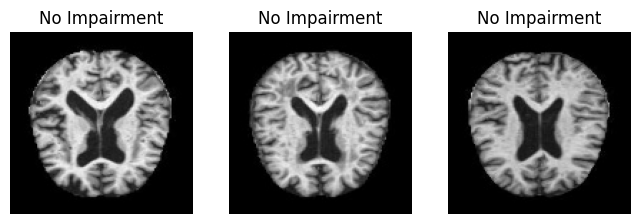

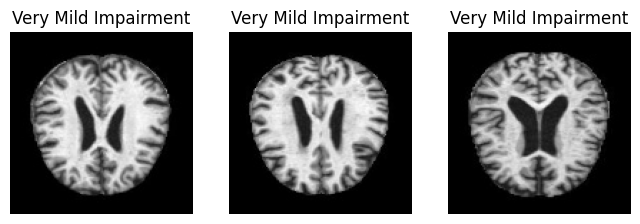

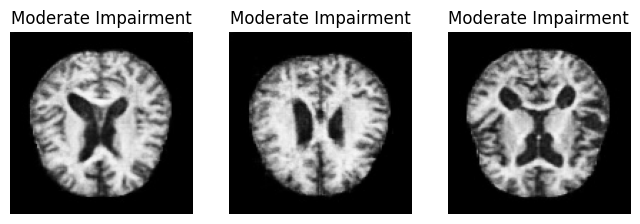

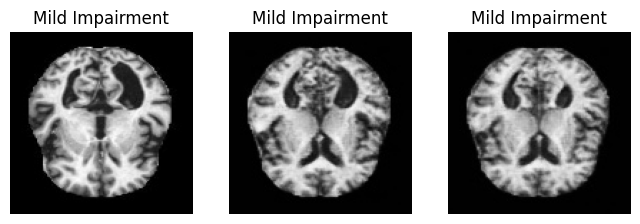

In [8]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# Path to dataset
dataset_path = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"

# Function to load and display sample images from each class
def show_sample_images(dataset_path, split='train', samples_per_class=3):
    split_path = os.path.join(dataset_path, split)
    classes = [cls for cls in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, cls))]
    
    for cls in classes:
        class_path = os.path.join(split_path, cls)
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sample_images = random.sample(images, min(samples_per_class, len(images)))
        
        plt.figure(figsize=(8, 4))
        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(1, samples_per_class, i+1)
            plt.imshow(img)
            plt.title(f"{cls}")
            plt.axis('off')
        plt.show()

# Show sample images from training set
show_sample_images(dataset_path, split='train', samples_per_class=3)

In [2]:
# ===============================================================
# Alzheimer MRI Dataset Preprocessing (Memory & Storage Efficient)
# ===============================================================

import os
from pathlib import Path
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from tqdm import tqdm

# ----------------------------
# Parameters
# ----------------------------
DATASET_PATH = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"
PREPROCESSED_DIR = "/kaggle/working/preprocessed_dataset"
IMG_SIZE = 128      # smaller input to save memory
BATCH_SIZE = 32
NUM_WORKERS = 2

# ----------------------------
# Transformations (for all models)
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # works for grayscale/RGB
])

# ----------------------------
# Create Preprocessed Directory
# ----------------------------
train_dir = Path(PREPROCESSED_DIR) / "train"
test_dir = Path(PREPROCESSED_DIR) / "test"
train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Load Original Dataset
# ----------------------------
original_train = datasets.ImageFolder(os.path.join(DATASET_PATH, "train"), transform=transform)
original_test = datasets.ImageFolder(os.path.join(DATASET_PATH, "test"), transform=transform)

# ----------------------------
# Function to save preprocessed dataset
# ----------------------------
def save_tensor_dataset(dataset, save_path):
    images = []
    labels = []
    for img, label in tqdm(dataset, desc=f"Preprocessing {save_path.name}"):
        images.append(img)
        labels.append(label)
    images = torch.stack(images)
    labels = torch.tensor(labels)
    torch.save((images, labels), save_path)
    print(f"Saved preprocessed dataset: {save_path} | Shape: {images.shape}, Labels: {labels.shape}")

# ----------------------------
# Save Train & Test
# ----------------------------
save_tensor_dataset(original_train, Path(PREPROCESSED_DIR)/"train.pt")
save_tensor_dataset(original_test, Path(PREPROCESSED_DIR)/"test.pt")

# ----------------------------
# Quick Loader to Test
# ----------------------------
train_images, train_labels = torch.load(Path(PREPROCESSED_DIR)/"train.pt")
test_images, test_labels = torch.load(Path(PREPROCESSED_DIR)/"test.pt")
print(f"Train images: {train_images.shape}, Train labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}, Test labels: {test_labels.shape}")

# ----------------------------
# Create DataLoaders (for training)
# ----------------------------
train_dataset = torch.utils.data.TensorDataset(train_images, train_labels)
test_dataset = torch.utils.data.TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Preprocessing complete. DataLoaders are ready!")


Preprocessing train.pt: 100%|██████████| 10240/10240 [01:20<00:00, 127.60it/s]


Saved preprocessed dataset: /kaggle/working/preprocessed_dataset/train.pt | Shape: torch.Size([10240, 3, 128, 128]), Labels: torch.Size([10240])


Preprocessing test.pt: 100%|██████████| 1279/1279 [00:09<00:00, 129.33it/s]


Saved preprocessed dataset: /kaggle/working/preprocessed_dataset/test.pt | Shape: torch.Size([1279, 3, 128, 128]), Labels: torch.Size([1279])
Train images: torch.Size([10240, 3, 128, 128]), Train labels: torch.Size([10240])
Test images: torch.Size([1279, 3, 128, 128]), Test labels: torch.Size([1279])
Preprocessing complete. DataLoaders are ready!


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 164MB/s]
/tmp/ipykernel_36/1721847940.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', 

Epoch 1/20: Train Loss=0.5839, Train Acc=0.7573, Val Loss=0.6329, Val Acc=0.7107
Best model saved at epoch 1 with Val Acc=0.7107


Epoch 2/20 - Validation: 100%|██████████| 40/40 [00:00<00:00, 54.80it/s]


Epoch 2/20: Train Loss=0.2843, Train Acc=0.8863, Val Loss=0.3509, Val Acc=0.8640
Best model saved at epoch 2 with Val Acc=0.8640


Epoch 3/20 - Validation: 100%|██████████| 40/40 [00:00<00:00, 53.78it/s]


...

Epoch 18/20: Train Loss=0.0178, Train Acc=0.9941, Val Loss=0.0629, Val Acc=0.9812


Epoch 19/20 - Validation: 100%|██████████| 40/40 [00:00<00:00, 53.66it/s]


Epoch 19/20: Train Loss=0.0145, Train Acc=0.9954, Val Loss=0.0594, Val Acc=0.9812


Epoch 20/20 - Validation: 100%|██████████| 40/40 [00:00<00:00, 55.77it/s]


Epoch 20/20: Train Loss=0.0158, Train Acc=0.9938, Val Loss=0.0622, Val Acc=0.9765


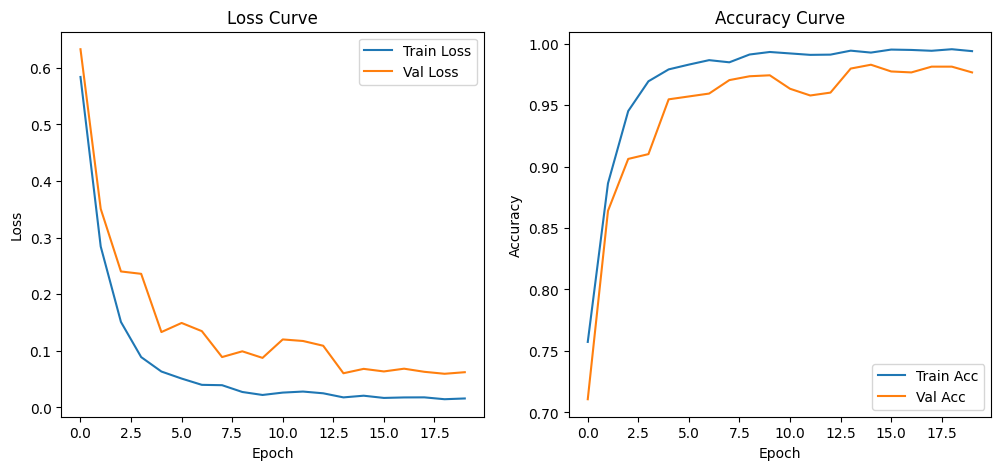


Evaluation Metrics Table per Class:


,Class,Accuracy,Precision,Recall,F1,Specificity,Sensitivity,ROC-AUC,Log Loss,Cohen Kappa,MCC,Balanced Acc
0,No Impairment,0.995309,0.988701,0.977654,0.983146,0.998182,0.977654,0.999924,0.011165,0.980421,0.980442,0.987918
1,Mild,0.999218,1.000000,0.916667,0.956522,1.000000,0.916667,1.000000,0.000800,0.956128,0.957049,0.958333
2,Moderate,0.980453,0.968037,0.993750,0.980725,0.967136,0.993750,0.998936,0.052738,0.960906,0.961246,0.980443
3,Very Mild,0.978108,0.983871,0.953125,0.968254,0.991576,0.953125,0.998359,0.058006,0.951554,0.951833,0.972351


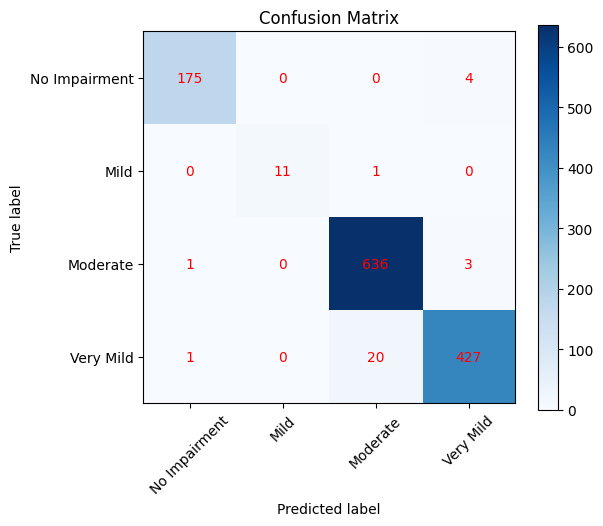

In [10]:
# ===============================================
# Training EfficientNet-B0 on Alzheimer MRI Dataset
# ===============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef,
                             confusion_matrix, balanced_accuracy_score)
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Parameters
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_CLASSES = 4
PREPROCESSED_DIR = "/kaggle/working/preprocessed_dataset"

# ----------------------------
# Load Preprocessed Dataset
# ----------------------------
train_images, train_labels = torch.load(f"{PREPROCESSED_DIR}/train.pt")
test_images, test_labels = torch.load(f"{PREPROCESSED_DIR}/test.pt")

train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# Initialize EfficientNet-B0
# ----------------------------
model = models.efficientnet_b0(pretrained=True)
# Change output layer for 4 classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

# ----------------------------
# Loss, Optimizer, Scaler (Mixed Precision)
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler()  # mixed precision

# ----------------------------
# Training Loop
# ----------------------------
best_acc = 0
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    running_corrects = 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    val_loss = 0
    val_corrects = 0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, 1).cpu().numpy())

    val_loss = val_loss / len(test_dataset)
    val_acc = val_corrects.double() / len(test_dataset)
    test_losses.append(val_loss)
    test_accuracies.append(val_acc.item())

    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={epoch_loss:.4f}, Train Acc={epoch_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # ----------------------------
    # Save Best Model
    # ----------------------------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "efficientnet_b0_best.pt")
        print(f"Best model saved at epoch {epoch+1} with Val Acc={best_acc:.4f}")

# ----------------------------
# Plot Loss & Accuracy Curves
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), train_losses, label='Train Loss')
plt.plot(range(EPOCHS), test_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), train_accuracies, label='Train Acc')
plt.plot(range(EPOCHS), test_accuracies, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# ----------------------------
# Compute Evaluation Metrics
# ----------------------------
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

metrics_table = {
    "Class": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Specificity": [],
    "Sensitivity": [],
    "ROC-AUC": [],
    "Log Loss": [],
    "Cohen Kappa": [],
    "MCC": [],
    "Balanced Acc": []
}

classes = ["No Impairment", "Mild", "Moderate", "Very Mild"]

for i, cls in enumerate(classes):
    cls_labels = (all_labels == i).astype(int)
    cls_preds = (all_preds == i).astype(int)
    cls_probs = all_probs[:, i]
    metrics_table["Class"].append(cls)
    metrics_table["Accuracy"].append(accuracy_score(cls_labels, cls_preds))
    metrics_table["Precision"].append(precision_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Recall"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["F1"].append(f1_score(cls_labels, cls_preds, zero_division=0))
    tn = np.sum((cls_labels==0) & (cls_preds==0))
    fp = np.sum((cls_labels==0) & (cls_preds==1))
    specificity = tn / (tn + fp + 1e-8)
    metrics_table["Specificity"].append(specificity)
    metrics_table["Sensitivity"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["ROC-AUC"].append(roc_auc_score(cls_labels, cls_probs))
    metrics_table["Log Loss"].append(log_loss(cls_labels, cls_probs))
    metrics_table["Cohen Kappa"].append(cohen_kappa_score(cls_labels, cls_preds))
    metrics_table["MCC"].append(matthews_corrcoef(cls_labels, cls_preds))
    metrics_table["Balanced Acc"].append(balanced_accuracy_score(cls_labels, cls_preds))

import pandas as pd
metrics_df = pd.DataFrame(metrics_table)
print("\nEvaluation Metrics Table per Class:")
display(metrics_df)

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), classes, rotation=45)
plt.yticks(range(NUM_CLASSES), classes)
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_36/3676533390.py:54: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_36/3676533390.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with t

Epoch 1/15
320/320 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.8070 - loss: 0.4471 - val_accuracy: 0.7717 - val_loss: 0.5392
Epoch 1: saving model to /kaggle/working/mobilenetv2_best.pt


/tmp/ipykernel_36/3676533390.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/15
320/320 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9318 - loss: 0.1766 - val_accuracy: 0.8796 - val_loss: 0.3069
Epoch 2: saving model to /kaggle/working/mobilenetv2_best.pt


/tmp/ipykernel_36/3676533390.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 13/15
320/320 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9969 - loss: 0.0107 - val_accuracy: 0.9633 - val_loss: 0.1149
Epoch 13: saving model to /kaggle/working/mobilenetv2_best.pt


/tmp/ipykernel_36/3676533390.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 14/15
320/320 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9956 - loss: 0.0130 - val_accuracy: 0.9531 - val_loss: 0.1728


/tmp/ipykernel_36/3676533390.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 15/15
320/320 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9915 - loss: 0.0248 - val_accuracy: 0.9461 - val_loss: 0.1271


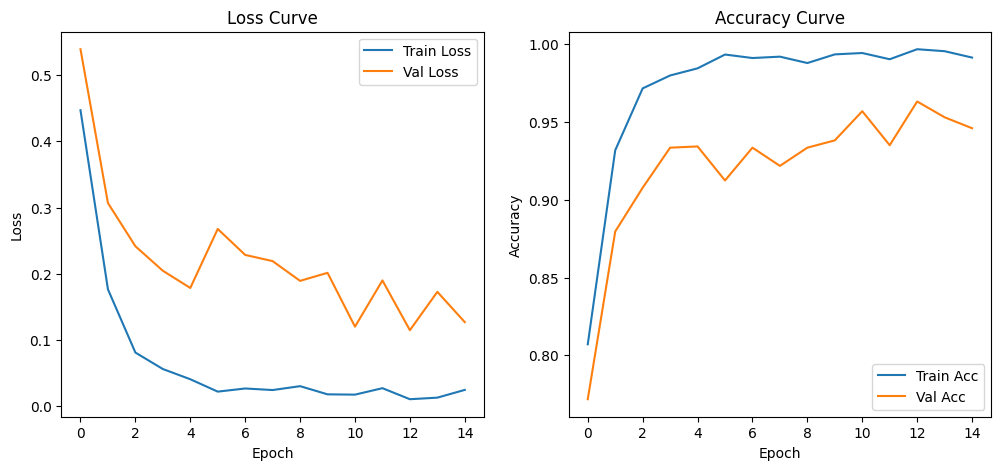


Evaluation Metrics Table per Class:


,Class,Accuracy,Precision,Recall,F1,Specificity,Sensitivity,ROC-AUC,Log Loss,Cohen Kappa,MCC,Balanced Acc
0,No Impairment,0.982017,0.981481,0.888268,0.932551,0.997273,0.888268,0.998136,0.048241,0.922207,0.923735,0.942770
1,Mild,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000178,1.000000,1.000000,1.000000
2,Moderate,0.955434,0.945038,0.967187,0.955985,0.943662,0.967187,0.995418,0.094338,0.910866,0.911117,0.955425
3,Very Mild,0.954652,0.933333,0.937500,0.935412,0.963899,0.937500,0.993296,0.105418,0.900473,0.900478,0.950699


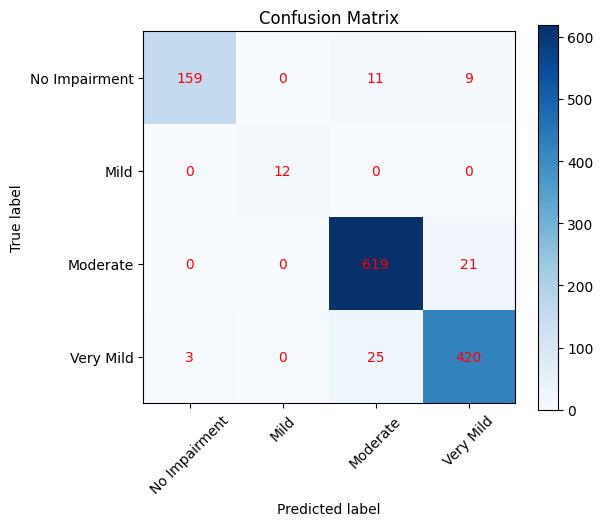

In [13]:
# ===============================================================
# MobileNetV2 Training on Alzheimer MRI Dataset
# Keras-style live logging + full evaluation metrics + curves
# ===============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef,
                             confusion_matrix, balanced_accuracy_score)
import matplotlib.pyplot as plt
import time

# ----------------------------
# Parameters
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-4
NUM_CLASSES = 4
PREPROCESSED_DIR = "/kaggle/working/preprocessed_dataset"
MODEL_SAVE_PATH = "/kaggle/working/mobilenetv2_best.pt"

# ----------------------------
# Load Preprocessed Dataset
# ----------------------------
train_images, train_labels = torch.load(f"{PREPROCESSED_DIR}/train.pt")
test_images, test_labels = torch.load(f"{PREPROCESSED_DIR}/test.pt")

train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# Initialize MobileNetV2
# ----------------------------
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

# ----------------------------
# Loss, Optimizer, Scaler
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler()

best_acc = 0
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

# ----------------------------
# Training Loop with Keras-style Logging
# ----------------------------
for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    running_loss = 0
    all_preds, all_labels_list = [], []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc = accuracy_score(all_labels_list, all_preds)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    val_loss = 0
    val_preds, val_labels_list, val_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())
            val_probs.extend(torch.softmax(outputs, 1).cpu().numpy())

    val_loss = val_loss / len(test_dataset)
    val_acc = accuracy_score(val_labels_list, val_preds)
    test_losses.append(val_loss)
    test_accuracies.append(val_acc)

    # Keras-style live print
    elapsed = int(time.time() - start_time)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{len(train_loader)}/{len(train_loader)} ━{'━'*30} {elapsed}s {elapsed*1000//len(train_loader)}ms/step - accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Epoch {epoch+1}: saving model to {MODEL_SAVE_PATH}")

# ----------------------------
# Plot Loss & Accuracy Curves
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), train_losses, label='Train Loss')
plt.plot(range(EPOCHS), test_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), train_accuracies, label='Train Acc')
plt.plot(range(EPOCHS), test_accuracies, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# ----------------------------
# Compute Evaluation Metrics per Class
# ----------------------------
all_labels = np.array(val_labels_list)
all_preds = np.array(val_preds)
all_probs = np.array(val_probs)

metrics_table = {
    "Class": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Specificity": [],
    "Sensitivity": [],
    "ROC-AUC": [],
    "Log Loss": [],
    "Cohen Kappa": [],
    "MCC": [],
    "Balanced Acc": []
}

classes = ["No Impairment", "Mild", "Moderate", "Very Mild"]

for i, cls in enumerate(classes):
    cls_labels = (all_labels == i).astype(int)
    cls_preds = (all_preds == i).astype(int)
    cls_probs = all_probs[:, i]
    tn = np.sum((cls_labels==0) & (cls_preds==0))
    fp = np.sum((cls_labels==0) & (cls_preds==1))
    specificity = tn / (tn + fp + 1e-8)

    metrics_table["Class"].append(cls)
    metrics_table["Accuracy"].append(accuracy_score(cls_labels, cls_preds))
    metrics_table["Precision"].append(precision_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Recall"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["F1"].append(f1_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Specificity"].append(specificity)
    metrics_table["Sensitivity"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["ROC-AUC"].append(roc_auc_score(cls_labels, cls_probs))
    metrics_table["Log Loss"].append(log_loss(cls_labels, cls_probs))
    metrics_table["Cohen Kappa"].append(cohen_kappa_score(cls_labels, cls_preds))
    metrics_table["MCC"].append(matthews_corrcoef(cls_labels, cls_preds))
    metrics_table["Balanced Acc"].append(balanced_accuracy_score(cls_labels, cls_preds))

metrics_df = pd.DataFrame(metrics_table)
print("\nEvaluation Metrics Table per Class:")
display(metrics_df)

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), classes, rotation=45)
plt.yticks(range(NUM_CLASSES), classes)
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()

In [15]:
import os
from pathlib import Path
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from tqdm import tqdm

# ----------------------------
# Parameters
# ----------------------------
DATASET_PATH = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"
PREPROCESSED_DIR = "/kaggle/working/preprocessed_dataset_transformers"  # different folder
IMG_SIZE = 224      # Transformers require 224x224
BATCH_SIZE = 32
NUM_WORKERS = 2

# ----------------------------
# Transformations (for all transformers)
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean for pretrained models
                         std=[0.229, 0.224, 0.225])   # ImageNet std for pretrained models
])

# ----------------------------
# Create Preprocessed Directory
# ----------------------------
train_dir = Path(PREPROCESSED_DIR) / "train"
test_dir = Path(PREPROCESSED_DIR) / "test"
train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Load Original Dataset
# ----------------------------
original_train = datasets.ImageFolder(os.path.join(DATASET_PATH, "train"), transform=transform)
original_test = datasets.ImageFolder(os.path.join(DATASET_PATH, "test"), transform=transform)

# ----------------------------
# Function to save preprocessed dataset
# ----------------------------
def save_tensor_dataset(dataset, save_path):
    images = []
    labels = []
    for img, label in tqdm(dataset, desc=f"Preprocessing {save_path.name}"):
        images.append(img)
        labels.append(label)
    images = torch.stack(images)
    labels = torch.tensor(labels)
    torch.save((images, labels), save_path)
    print(f"Saved preprocessed dataset: {save_path} | Shape: {images.shape}, Labels: {labels.shape}")

# ----------------------------
# Save Train & Test for Transformers
# ----------------------------
save_tensor_dataset(original_train, Path(PREPROCESSED_DIR)/"train_transformers.pt")
save_tensor_dataset(original_test, Path(PREPROCESSED_DIR)/"test_transformers.pt")

# ----------------------------
# Quick Loader to Test
# ----------------------------
train_images, train_labels = torch.load(Path(PREPROCESSED_DIR)/"train_transformers.pt")
test_images, test_labels = torch.load(Path(PREPROCESSED_DIR)/"test_transformers.pt")
print(f"Train images: {train_images.shape}, Train labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}, Test labels: {test_labels.shape}")

# ----------------------------
# Create DataLoaders (for training)
# ----------------------------
train_dataset = torch.utils.data.TensorDataset(train_images, train_labels)
test_dataset = torch.utils.data.TensorDataset(test_images, test_labels)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Transformer preprocessing complete. DataLoaders are ready!")

Preprocessing train_transformers.pt: 100%|██████████| 10240/10240 [00:24<00:00, 418.68it/s]


Saved preprocessed dataset: /kaggle/working/preprocessed_dataset_transformers/train_transformers.pt | Shape: torch.Size([10240, 3, 224, 224]), Labels: torch.Size([10240])


Preprocessing test_transformers.pt: 100%|██████████| 1279/1279 [00:05<00:00, 223.40it/s]


Saved preprocessed dataset: /kaggle/working/preprocessed_dataset_transformers/test_transformers.pt | Shape: torch.Size([1279, 3, 224, 224]), Labels: torch.Size([1279])
Train images: torch.Size([10240, 3, 224, 224]), Train labels: torch.Size([10240])
Test images: torch.Size([1279, 3, 224, 224]), Test labels: torch.Size([1279])
Transformer preprocessing complete. DataLoaders are ready!


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

/tmp/ipykernel_36/1067363801.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_36/1067363801.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - accuracy: 0.7623 - loss: 0.5248 - val_accuracy: 0.6349 - val_loss: 0.7744
Epoch 1: saving model to /kaggle/working/deit_tiny_transformers.pt


/tmp/ipykernel_36/1067363801.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.8975 - loss: 0.2643 - val_accuracy: 0.8694 - val_loss: 0.3357
Epoch 2: saving model to /kaggle/working/deit_tiny_transformers.pt


...

Epoch 13/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.9905 - loss: 0.0279 - val_accuracy: 0.9484 - val_loss: 0.1646


/tmp/ipykernel_36/1067363801.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 14/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.9875 - loss: 0.0360 - val_accuracy: 0.9593 - val_loss: 0.1272
Epoch 14: saving model to /kaggle/working/deit_tiny_transformers.pt


/tmp/ipykernel_36/1067363801.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 15/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.9919 - loss: 0.0230 - val_accuracy: 0.9062 - val_loss: 0.2884


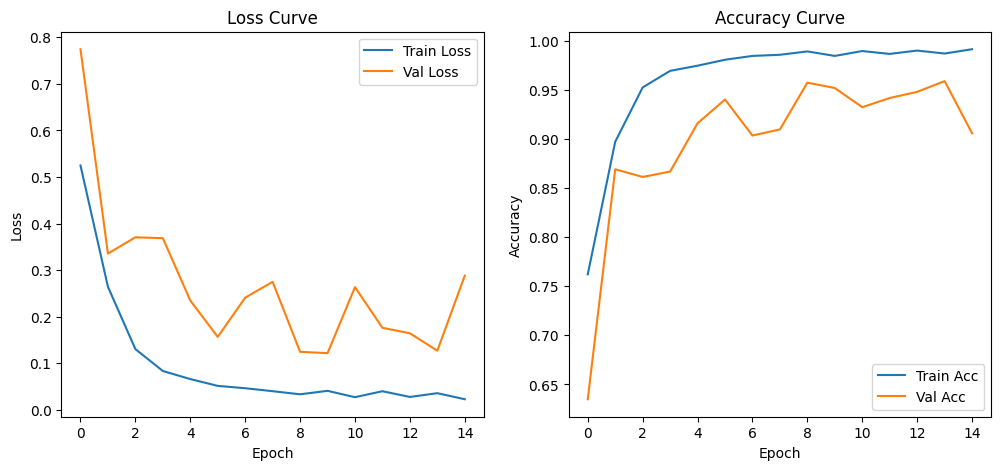


Evaluation Metrics Table per Class:


,Class,Accuracy,Precision,Recall,F1,Specificity,Sensitivity,ROC-AUC,Log Loss,Cohen Kappa,MCC,Balanced Acc
0,No Impairment,0.969507,0.821101,1.000000,0.901763,0.964545,1.000000,0.999157,0.090210,0.883922,0.889938,0.982273
1,Mild,0.998436,1.000000,0.833333,0.909091,1.000000,0.833333,0.999868,0.003453,0.908309,0.912151,0.916667
2,Moderate,0.917905,0.994455,0.840625,0.911092,0.995305,0.840625,0.995511,0.247593,0.835829,0.846026,0.917965
3,Very Mild,0.926505,0.847059,0.964286,0.901879,0.906137,0.964286,0.984764,0.204059,0.843521,0.848050,0.935211


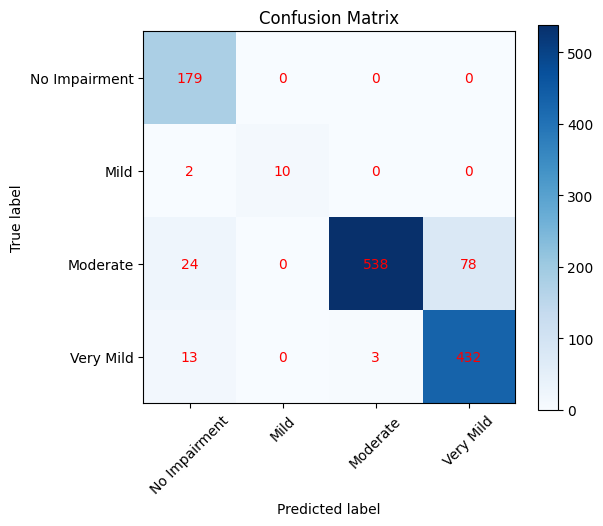

In [17]:
# ===============================================================
# DeiT-Tiny Training on Alzheimer MRI Dataset (Transformer-ready)
# Keras-style live logging + full evaluation metrics + curves
# ===============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import timm
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef,
                             confusion_matrix, balanced_accuracy_score)
import matplotlib.pyplot as plt
import time

# ----------------------------
# Parameters
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16   # Transformers require smaller batch
EPOCHS = 15
LEARNING_RATE = 1e-4
NUM_CLASSES = 4
PREPROCESSED_DIR = "/kaggle/working/preprocessed_dataset_transformers"  # NEW DATASET
MODEL_SAVE_PATH = "/kaggle/working/deit_tiny_transformers.pt"

# ----------------------------
# Load Preprocessed Dataset
# ----------------------------
train_images, train_labels = torch.load(f"{PREPROCESSED_DIR}/train_transformers.pt")
test_images, test_labels = torch.load(f"{PREPROCESSED_DIR}/test_transformers.pt")

train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# Initialize DeiT-Tiny
# ----------------------------
model = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# ----------------------------
# Loss, Optimizer, Scaler
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler()

best_acc = 0
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

# ----------------------------
# Training Loop with Keras-style Logging
# ----------------------------
for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    running_loss = 0
    all_preds, all_labels_list = [], []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc = accuracy_score(all_labels_list, all_preds)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    val_loss = 0
    val_preds, val_labels_list, val_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())
            val_probs.extend(torch.softmax(outputs, 1).cpu().numpy())

    val_loss = val_loss / len(test_dataset)
    val_acc = accuracy_score(val_labels_list, val_preds)
    test_losses.append(val_loss)
    test_accuracies.append(val_acc)

    # Keras-style live print
    elapsed = int(time.time() - start_time)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{len(train_loader)}/{len(train_loader)} ━{'━'*30} {elapsed}s {elapsed*1000//len(train_loader)}ms/step - "
          f"accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Epoch {epoch+1}: saving model to {MODEL_SAVE_PATH}")

# ----------------------------
# Plot Loss & Accuracy Curves
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), train_losses, label='Train Loss')
plt.plot(range(EPOCHS), test_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), train_accuracies, label='Train Acc')
plt.plot(range(EPOCHS), test_accuracies, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# ----------------------------
# Compute Evaluation Metrics per Class
# ----------------------------
all_labels = np.array(val_labels_list)
all_preds = np.array(val_preds)
all_probs = np.array(val_probs)

metrics_table = {
    "Class": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Specificity": [],
    "Sensitivity": [],
    "ROC-AUC": [],
    "Log Loss": [],
    "Cohen Kappa": [],
    "MCC": [],
    "Balanced Acc": []
}

classes = ["No Impairment", "Mild", "Moderate", "Very Mild"]

for i, cls in enumerate(classes):
    cls_labels = (all_labels == i).astype(int)
    cls_preds = (all_preds == i).astype(int)
    cls_probs = all_probs[:, i]
    tn = np.sum((cls_labels==0) & (cls_preds==0))
    fp = np.sum((cls_labels==0) & (cls_preds==1))
    specificity = tn / (tn + fp + 1e-8)

    metrics_table["Class"].append(cls)
    metrics_table["Accuracy"].append(accuracy_score(cls_labels, cls_preds))
    metrics_table["Precision"].append(precision_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Recall"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["F1"].append(f1_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Specificity"].append(specificity)
    metrics_table["Sensitivity"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["ROC-AUC"].append(roc_auc_score(cls_labels, cls_probs))
    metrics_table["Log Loss"].append(log_loss(cls_labels, cls_probs))
    metrics_table["Cohen Kappa"].append(cohen_kappa_score(cls_labels, cls_preds))
    metrics_table["MCC"].append(matthews_corrcoef(cls_labels, cls_preds))
    metrics_table["Balanced Acc"].append(balanced_accuracy_score(cls_labels, cls_preds))

metrics_df = pd.DataFrame(metrics_table)
print("\nEvaluation Metrics Table per Class:")
display(metrics_df)

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), classes, rotation=45)
plt.yticks(range(NUM_CLASSES), classes)
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()

/tmp/ipykernel_36/2790526610.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_36/2790526610.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93s 145ms/step - accuracy: 0.7104 - loss: 0.6120 - val_accuracy: 0.5160 - val_loss: 1.0483
Epoch 1: saving model to /kaggle/working/swin_tiny_transformers.pt


/tmp/ipykernel_36/2790526610.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93s 145ms/step - accuracy: 0.8674 - loss: 0.3116 - val_accuracy: 0.8655 - val_loss: 0.3394
Epoch 2: saving model to /kaggle/working/swin_tiny_transformers.pt


/tmp/ipykernel_36/2790526610.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 13/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93s 145ms/step - accuracy: 0.9900 - loss: 0.0274 - val_accuracy: 0.9687 - val_loss: 0.0731


/tmp/ipykernel_36/2790526610.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 14/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92s 143ms/step - accuracy: 0.9938 - loss: 0.0178 - val_accuracy: 0.9742 - val_loss: 0.0677


/tmp/ipykernel_36/2790526610.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 15/15
640/640 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92s 143ms/step - accuracy: 0.9914 - loss: 0.0237 - val_accuracy: 0.9617 - val_loss: 0.1481


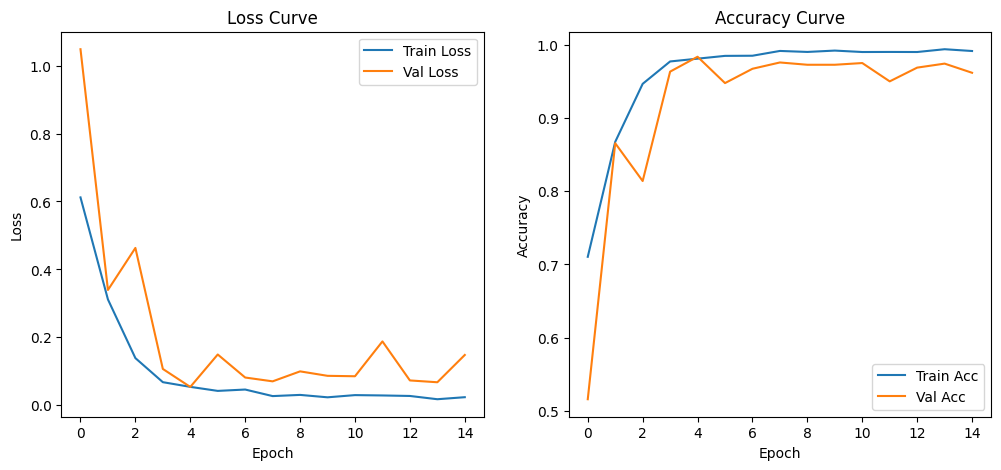


Evaluation Metrics Table per Class:


,Class,Accuracy,Precision,Recall,F1,Specificity,Sensitivity,ROC-AUC,Log Loss,Cohen Kappa,MCC,Balanced Acc
0,No Impairment,0.989836,0.951087,0.977654,0.964187,0.991818,0.977654,0.998614,0.031580,0.958266,0.958390,0.984736
1,Mild,0.998436,1.000000,0.833333,0.909091,1.000000,0.833333,1.000000,0.002262,0.908309,0.912151,0.916667
2,Moderate,0.967944,0.990180,0.945312,0.967226,0.990610,0.945312,0.996589,0.134217,0.935890,0.936853,0.967961
3,Very Mild,0.967162,0.928270,0.982143,0.954447,0.959085,0.982143,0.996141,0.116717,0.928806,0.929710,0.970614


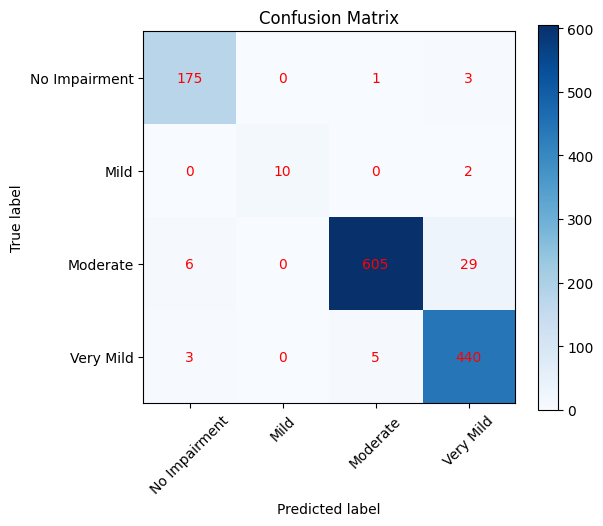

In [18]:
# =============================================================== 
# Swin Transformer Tiny (Swin-T) Training on Alzheimer MRI Dataset
# Keras-style live logging + full evaluation metrics + curves
# ===============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import timm
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef,
                             confusion_matrix, balanced_accuracy_score)
import matplotlib.pyplot as plt
import time

# ----------------------------
# Parameters
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 1e-4
NUM_CLASSES = 4
PREPROCESSED_DIR = "/kaggle/working/preprocessed_dataset_transformers"  # UPDATED PATH
MODEL_SAVE_PATH = "/kaggle/working/swin_tiny_transformers.pt"

# ----------------------------
# Load Preprocessed Dataset
# ----------------------------
train_images, train_labels = torch.load(f"{PREPROCESSED_DIR}/train_transformers.pt")
test_images, test_labels = torch.load(f"{PREPROCESSED_DIR}/test_transformers.pt")

train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# Initialize Swin-Tiny
# ----------------------------
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# ----------------------------
# Loss, Optimizer, Scaler
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler()

best_acc = 0
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

# ----------------------------
# Training Loop with Keras-style Logging
# ----------------------------
for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    running_loss = 0
    all_preds, all_labels_list = [], []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc = accuracy_score(all_labels_list, all_preds)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    val_loss = 0
    val_preds, val_labels_list, val_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())
            val_probs.extend(torch.softmax(outputs, 1).cpu().numpy())

    val_loss = val_loss / len(test_dataset)
    val_acc = accuracy_score(val_labels_list, val_preds)
    test_losses.append(val_loss)
    test_accuracies.append(val_acc)

    # Keras-style live print
    elapsed = int(time.time() - start_time)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{len(train_loader)}/{len(train_loader)} ━{'━'*30} {elapsed}s {elapsed*1000//len(train_loader)}ms/step - "
          f"accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Epoch {epoch+1}: saving model to {MODEL_SAVE_PATH}")

# ----------------------------
# Plot Loss & Accuracy Curves
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), train_losses, label='Train Loss')
plt.plot(range(EPOCHS), test_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), train_accuracies, label='Train Acc')
plt.plot(range(EPOCHS), test_accuracies, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# ----------------------------
# Compute Evaluation Metrics per Class
# ----------------------------
all_labels = np.array(val_labels_list)
all_preds = np.array(val_preds)
all_probs = np.array(val_probs)

metrics_table = {
    "Class": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Specificity": [],
    "Sensitivity": [],
    "ROC-AUC": [],
    "Log Loss": [],
    "Cohen Kappa": [],
    "MCC": [],
    "Balanced Acc": []
}

classes = ["No Impairment", "Mild", "Moderate", "Very Mild"]

for i, cls in enumerate(classes):
    cls_labels = (all_labels == i).astype(int)
    cls_preds = (all_preds == i).astype(int)
    cls_probs = all_probs[:, i]
    tn = np.sum((cls_labels==0) & (cls_preds==0))
    fp = np.sum((cls_labels==0) & (cls_preds==1))
    specificity = tn / (tn + fp + 1e-8)

    metrics_table["Class"].append(cls)
    metrics_table["Accuracy"].append(accuracy_score(cls_labels, cls_preds))
    metrics_table["Precision"].append(precision_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Recall"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["F1"].append(f1_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Specificity"].append(specificity)
    metrics_table["Sensitivity"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["ROC-AUC"].append(roc_auc_score(cls_labels, cls_probs))
    metrics_table["Log Loss"].append(log_loss(cls_labels, cls_probs))
    metrics_table["Cohen Kappa"].append(cohen_kappa_score(cls_labels, cls_preds))
    metrics_table["MCC"].append(matthews_corrcoef(cls_labels, cls_preds))
    metrics_table["Balanced Acc"].append(balanced_accuracy_score(cls_labels, cls_preds))

metrics_df = pd.DataFrame(metrics_table)
print("\nEvaluation Metrics Table per Class:")
display(metrics_df)

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), classes, rotation=45)
plt.yticks(range(NUM_CLASSES), classes)
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()

Epoch 1/15: 100%|██████████| 640/640 [00:15<00:00, 40.90it/s]


Epoch 1/15 - 16s - accuracy: 0.2542 - loss: 1.2145 - val_accuracy: 0.0094 - val_loss: 1.2153
Epoch 1: saved model to /kaggle/working/capsnet_best.pt


Epoch 2/15: 100%|██████████| 640/640 [00:15<00:00, 40.84it/s]


Epoch 2/15 - 16s - accuracy: 0.2472 - loss: 1.2126 - val_accuracy: 0.0094 - val_loss: 1.2153


Epoch 3/15: 100%|██████████| 640/640 [00:15<00:00, 40.84it/s]


...

Epoch 14/15: 100%|██████████| 640/640 [00:15<00:00, 41.00it/s]


Epoch 14/15 - 16s - accuracy: 0.9979 - loss: 0.0250 - val_accuracy: 0.9453 - val_loss: 0.0835


Epoch 15/15: 100%|██████████| 640/640 [00:15<00:00, 41.02it/s]


Epoch 15/15 - 16s - accuracy: 0.9984 - loss: 0.0229 - val_accuracy: 0.9531 - val_loss: 0.0804

Evaluation Metrics Table per Class:


,Class,Accuracy,Precision,Recall,F1,Specificity,Sensitivity,ROC-AUC,Log Loss,Cohen Kappa,MCC,Balanced Acc
0,No Impairment,0.985927,0.960000,0.938547,0.949153,0.993636,0.938547,0.997938,0.353002,0.940987,0.941068,0.966092
1,Mild,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.216208,1.000000,1.000000,1.000000
2,Moderate,0.964034,0.951368,0.978125,0.964561,0.949922,0.978125,0.992916,0.629826,0.928067,0.928435,0.964023
3,Very Mild,0.956216,0.951613,0.921875,0.936508,0.974729,0.921875,0.988713,0.535028,0.903108,0.903373,0.948302


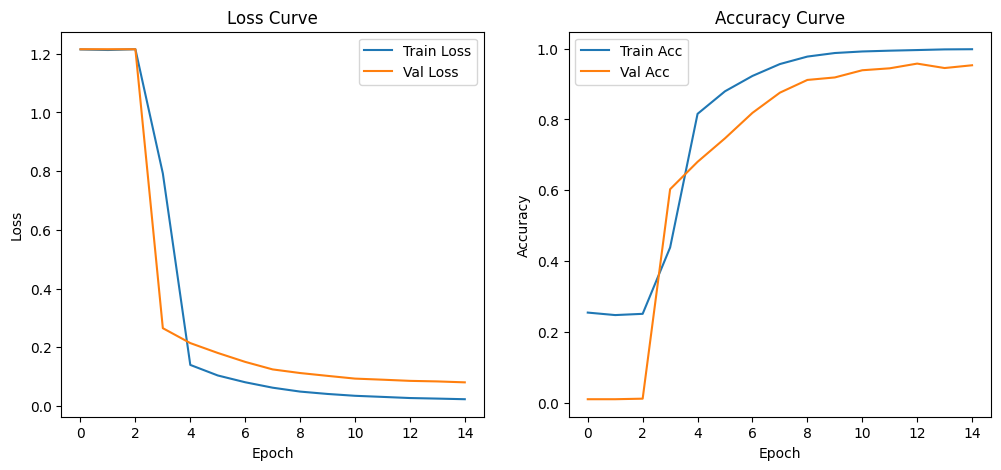

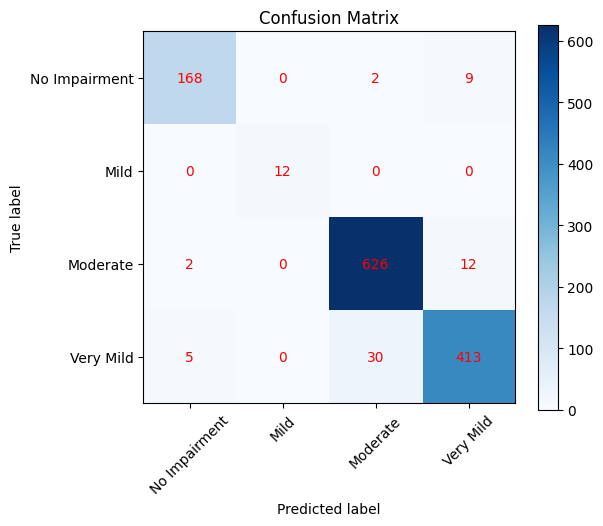

In [30]:
# ===============================================================
# CapsNet for 4-class MRI Dataset with Evaluation Metrics
# ===============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef,
                             confusion_matrix, balanced_accuracy_score)
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# ----------------------------
# Parameters
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 1e-3
NUM_CLASSES = 4
IMG_SIZE = 128
PREPROCESSED_DIR = "/kaggle/working/preprocessed_dataset"
MODEL_SAVE_PATH = "/kaggle/working/capsnet_best.pt"
RECONSTRUCTION_LOSS_WEIGHT = 0.0005
GRAD_CLIP = 1.0
CLASS_NAMES = ["No Impairment", "Mild", "Moderate", "Very Mild"]

# ----------------------------
# Load Dataset
# ----------------------------
train_images, train_labels = torch.load(f"{PREPROCESSED_DIR}/train.pt")
test_images, test_labels = torch.load(f"{PREPROCESSED_DIR}/test.pt")

# Convert grayscale -> 3-channel if needed
if train_images.shape[1] == 1:
    train_images = train_images.repeat(1, 3, 1, 1)
if test_images.shape[1] == 1:
    test_images = test_images.repeat(1, 3, 1, 1)

train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# Capsule Network
# ----------------------------
class CapsuleLayer(nn.Module):
    def __init__(self, num_capsules, in_dim, out_dim):
        super().__init__()
        self.num_capsules = num_capsules
        self.capsules = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_capsules)])

    def forward(self, x):
        u = [caps(x).unsqueeze(1) for caps in self.capsules]
        u = torch.cat(u, dim=1)
        return self.squash(u)

    def squash(self, s, dim=-1):
        squared_norm = (s**2).sum(dim=dim, keepdim=True)
        scale = squared_norm / (1 + squared_norm) / torch.sqrt(squared_norm + 1e-8)
        return scale * s

class CapsNet(nn.Module):
    def __init__(self, img_size=128, in_channels=3, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, stride=2)
        self.primary_caps = nn.Conv2d(64, 128, kernel_size=5, stride=2)
        self.caps_layer = CapsuleLayer(num_capsules=num_classes, in_dim=128*29*29, out_dim=16)
        self.reconstruction = nn.Sequential(
            nn.Linear(16*num_classes, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, in_channels*img_size*img_size),
            nn.Sigmoid()
        )

    def forward(self, x, labels=None):
        batch_size = x.size(0)
        x = F.relu(self.conv1(x))
        x = F.relu(self.primary_caps(x))
        x = x.view(batch_size, -1)
        caps_output = self.caps_layer(x)  # batch x num_caps x 16
        lengths = caps_output.norm(dim=-1)

        # Masking
        if labels is None:
            max_indices = lengths.max(1)[1]
            labels = torch.eye(NUM_CLASSES).to(DEVICE)[max_indices]
        else:
            labels = F.one_hot(labels, num_classes=NUM_CLASSES).float()

        masked = caps_output * labels.unsqueeze(-1)
        recon_input = masked.view(batch_size, -1)
        reconstructions = self.reconstruction(recon_input)
        reconstructions = reconstructions.view(batch_size, 3, IMG_SIZE, IMG_SIZE)

        return lengths, reconstructions

# ----------------------------
# Margin Loss
# ----------------------------
def margin_loss(labels, lengths):
    m_plus, m_minus, lambda_ = 0.9, 0.1, 0.5
    labels_one_hot = F.one_hot(labels, NUM_CLASSES).float()
    loss = labels_one_hot * F.relu(m_plus - lengths).pow(2) + \
           lambda_ * (1 - labels_one_hot) * F.relu(lengths - m_minus).pow(2)
    return loss.sum(dim=1).mean()

# ----------------------------
# Model, Optimizer
# ----------------------------
model = CapsNet(img_size=IMG_SIZE, in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_acc = 0
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

# ----------------------------
# Training Loop
# ----------------------------
for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    running_loss = 0
    all_preds, all_labels_list = [], []

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs, reconstructions = model(inputs, labels)
        loss_class = margin_loss(labels, outputs)
        loss_recon = F.mse_loss(reconstructions, inputs)
        loss = loss_class + RECONSTRUCTION_LOSS_WEIGHT * loss_recon
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc = accuracy_score(all_labels_list, all_preds)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    val_loss = 0
    val_preds, val_labels_list, val_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs, reconstructions = model(inputs, labels)
            loss_class = margin_loss(labels, outputs)
            loss_recon = F.mse_loss(reconstructions, inputs)
            loss = loss_class + RECONSTRUCTION_LOSS_WEIGHT * loss_recon
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())
            val_probs.extend(F.softmax(outputs, dim=1).cpu().numpy())

    val_loss = val_loss / len(test_dataset)
    val_acc = accuracy_score(val_labels_list, val_preds)
    test_losses.append(val_loss)
    test_accuracies.append(val_acc)

    elapsed = int(time.time() - start_time)
    print(f"Epoch {epoch+1}/{EPOCHS} - {elapsed}s - accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Epoch {epoch+1}: saved model to {MODEL_SAVE_PATH}")

# ===============================================================
# Evaluation Metrics Table per Class
# ===============================================================
all_labels = np.array(val_labels_list)
all_preds = np.array(val_preds)
all_probs = np.array(val_probs)

metrics_table = {"Class": [], "Accuracy": [], "Precision": [], "Recall": [], "F1": [],
                 "Specificity": [], "Sensitivity": [], "ROC-AUC": [], "Log Loss": [],
                 "Cohen Kappa": [], "MCC": [], "Balanced Acc": []}

for i, cls in enumerate(CLASS_NAMES):
    cls_labels = (all_labels == i).astype(int)
    cls_preds = (all_preds == i).astype(int)
    cls_probs = all_probs[:, i]
    tn = np.sum((cls_labels==0) & (cls_preds==0))
    fp = np.sum((cls_labels==0) & (cls_preds==1))
    specificity = tn / (tn + fp + 1e-8)

    metrics_table["Class"].append(cls)
    metrics_table["Accuracy"].append(accuracy_score(cls_labels, cls_preds))
    metrics_table["Precision"].append(precision_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Recall"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["F1"].append(f1_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["Specificity"].append(specificity)
    metrics_table["Sensitivity"].append(recall_score(cls_labels, cls_preds, zero_division=0))
    metrics_table["ROC-AUC"].append(roc_auc_score(cls_labels, cls_probs))
    metrics_table["Log Loss"].append(log_loss(cls_labels, cls_probs))
    metrics_table["Cohen Kappa"].append(cohen_kappa_score(cls_labels, cls_preds))
    metrics_table["MCC"].append(matthews_corrcoef(cls_labels, cls_preds))
    metrics_table["Balanced Acc"].append(balanced_accuracy_score(cls_labels, cls_preds))

metrics_df = pd.DataFrame(metrics_table)
print("\nEvaluation Metrics Table per Class:")
display(metrics_df)

# ===============================================================
# Loss & Accuracy Curves
# ===============================================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), train_losses, label='Train Loss')
plt.plot(range(EPOCHS), test_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), train_accuracies, label='Train Acc')
plt.plot(range(EPOCHS), test_accuracies, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# ===============================================================
# Confusion Matrix
# ===============================================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()